# LLM-judge OCEAN-score-vector cosine similarity (vanton4_paired_dpo OCEAN±)

For each of the 10 OCEAN± LoRAs, build a 5-vector of
`(judge_score @ scale=1) - (judge_score @ scale=0)` over the 5 OCEAN trait question sets.
Then compute the 10×10 pairwise cosine-similarity matrix and plot.

Compare visually with the cosine-similarity heatmap of the LoRA *weights*
(after rank-1 reduction) in
`scripts_dev/flatten_loras/ocean_flattened_exploration_without_control_models.ipynb`
(cell `f3b2eb9c`).

**Data fetched:** only sweep-level `analysis/grid_summary.jsonl` aggregates from HF
(50 small JSON files, ~1 MB total). No LoRA weights, no rollouts, no model loading.

In [9]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# Project root on sys.path for src_dev imports.
REPO_ROOT = Path('.').resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'src_dev').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src_dev.common.lora_catalogue import HF_REPO, OCEAN_REGISTRY
from src_dev.evals.llm_judge_sweep.cell_identity import (
    AdapterSpec,
    rollout_fingerprint,
    sweep_hf_root,
)
from src_dev.utils.hf_hub import download_path_to_dir

# Match scripts_dev/evals/llm_judge_sweep/configs/vanton4_paired_dpo/_shared.py.
# Changes here change the fingerprint and break HF cache hits.
BASE_MODEL = 'meta-llama/Llama-3.1-8B-Instruct'
MODEL_SLUG = 'llama-3.1-8b-it'
EVAL_NAME = 'llm_judge_lora_scale_sweep'
MAX_SAMPLES = 240
SEED = 42
NUM_ROLLOUTS_PER_PROMPT = 1
ASSISTANT_TEMPERATURE = 1.0
ASSISTANT_TOP_P = 1.0
ASSISTANT_MAX_NEW_TOKENS = 2048

# Standard OCEAN ordering used by both axes of the matrix.
OCEAN_TRAITS = [
    'openness',
    'conscientiousness',
    'extraversion',
    'agreeableness',
    'neuroticism',
]
OCEAN_TRAIT_LETTER = {t: t[0].upper() for t in OCEAN_TRAITS}

# Adapter slug ordering: openness, conscientiousness, ..., each followed by + then -.
# Matches the row/column order of the reference adapter-weight heatmap so the two
# matrices are visually aligned.
ADAPTER_SLUGS = [
    f'{trait[0]}_{sign}'
    for trait in OCEAN_TRAITS
    for sign in ('plus', 'minus')
]
print('Adapter order:', ADAPTER_SLUGS)
print('Trait order:  ', OCEAN_TRAITS)

Adapter order: ['o_plus', 'o_minus', 'c_plus', 'c_minus', 'e_plus', 'e_minus', 'a_plus', 'a_minus', 'n_plus', 'n_minus']
Trait order:   ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']


## Path construction

For each `(adapter_slug, evaluating_trait)`, build the HF prefix that the
`runner_cells.py` sweep wrote to. The fingerprint depends on the dataset path,
so it differs per evaluating trait. Helpers are reused as-is from the
`cell_sweep` / `llm_judge_sweep` modules so the path matches what the runner produces.

In [10]:
def adapter_for(slug: str) -> AdapterSpec:
    trait_def = OCEAN_REGISTRY[slug]
    ref = f'{HF_REPO}::{trait_def.adapter_path_in_repo}'
    return AdapterSpec.from_ref(ref)

def fingerprint_for(evaluating_trait: str) -> str:
    return rollout_fingerprint(
        base_model=BASE_MODEL,
        dataset_path=f'data/ocean_open_ended/{evaluating_trait}.jsonl',
        max_samples=MAX_SAMPLES,
        seed=SEED,
        num_rollouts_per_prompt=NUM_ROLLOUTS_PER_PROMPT,
        assistant_temperature=ASSISTANT_TEMPERATURE,
        assistant_top_p=ASSISTANT_TOP_P,
        assistant_max_new_tokens=ASSISTANT_MAX_NEW_TOKENS,
    )

def sweep_prefix(slug: str, evaluating_trait: str) -> str:
    fp = fingerprint_for(evaluating_trait)
    return sweep_hf_root(
        [adapter_for(slug)],
        model_slug=MODEL_SLUG,
        eval_name=EVAL_NAME,
        fingerprint=fp,
    )

# Sanity-check one prefix.
print(sweep_prefix('a_plus', 'agreeableness'))
print(sweep_prefix('a_plus', 'neuroticism'))

fine_tuning/llama-3.1-8b-it/ocean/agreeableness/amplifier/vanton4_paired_dpo/evals/llm_judge_lora_scale_sweep/0705e3276a
fine_tuning/llama-3.1-8b-it/ocean/agreeableness/amplifier/vanton4_paired_dpo/evals/llm_judge_lora_scale_sweep/b2a49f1b4d


## Download `analysis/grid_summary.jsonl` for all 50 (adapter, evaluating-trait) pairs

Each `grid_summary.jsonl` is a few KB; total fetch is ~1 MB and cached locally
under `scratch/llm_judge_grid_cache/`.

In [11]:
CACHE_DIR = Path('scratch/llm_judge_grid_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def fetch_grid_summary(slug: str, evaluating_trait: str) -> Path:
    """Download analysis/grid_summary.jsonl for one (adapter, trait) pair.

    Returns the path to the local file. Cached: re-runs are no-ops.
    """
    prefix = sweep_prefix(slug, evaluating_trait)
    target = CACHE_DIR / slug / evaluating_trait
    local_file = target / 'grid_summary.jsonl'
    if local_file.exists():
        return local_file
    target.mkdir(parents=True, exist_ok=True)
    download_path_to_dir(
        repo_id=HF_REPO,
        path_in_repo=f'{prefix}/analysis',
        target_dir=target,
        allow_patterns=['grid_summary.jsonl'],
    )
    if not local_file.exists():
        raise FileNotFoundError(f'No grid_summary.jsonl at {prefix}/analysis')
    return local_file

errors: list[tuple[str, str, str]] = []
for slug in ADAPTER_SLUGS:
    for trait in OCEAN_TRAITS:
        try:
            fetch_grid_summary(slug, trait)
        except Exception as exc:  # noqa: BLE001
            errors.append((slug, trait, f'{type(exc).__name__}: {exc}'))
if errors:
    print(f'{len(errors)}/{len(ADAPTER_SLUGS) * len(OCEAN_TRAITS)} fetches failed:')
    for s, t, msg in errors[:10]:
        print(f'  {s} on {t}: {msg}')
else:
    print(f'OK — all {len(ADAPTER_SLUGS) * len(OCEAN_TRAITS)} grid_summary.jsonl fetched.')

OK — all 50 grid_summary.jsonl fetched.


## Parse: extract `score@scale=0` and `score@scale=1` per (adapter, trait)

Each `grid_summary.jsonl` has one line per `(cell, metric)` aggregate. We filter to
`metric == "<evaluating_trait>_v2"` (the cross-trait sweeps judge with the
evaluating trait's metric, regardless of which adapter they're scoring) and pick:

- baseline mean (`tier == "baseline"`) → score at scale 0
- single-adapter mean where `cell_entries[0].scale == 1.0` → score at scale 1

Delta = `mean@scale=1 - mean@scale=0`.

In [12]:
def parse_means(slug: str, evaluating_trait: str) -> tuple[float, float]:
    """Return (mean@scale=0, mean@scale=1) for the trait_v2 metric."""
    metric_name = f'{evaluating_trait}_v2'
    path = fetch_grid_summary(slug, evaluating_trait)
    baseline = None
    scale_one = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            if row.get('metric') != metric_name:
                continue
            tier = row.get('tier')
            if tier == 'baseline':
                baseline = row['mean']
            elif tier == 'single_adapter':
                entries = row.get('cell_entries') or []
                if entries and abs(float(entries[0]['scale']) - 1.0) < 1e-9:
                    scale_one = row['mean']
    if baseline is None or scale_one is None:
        raise ValueError(
            f'Missing baseline/scale=1 for {slug} on {evaluating_trait}: '
            f'baseline={baseline}, scale_one={scale_one}'
        )
    return float(baseline), float(scale_one)

deltas = np.zeros((len(ADAPTER_SLUGS), len(OCEAN_TRAITS)))
raw_baseline = np.zeros_like(deltas)
raw_scale1 = np.zeros_like(deltas)
for i, slug in enumerate(ADAPTER_SLUGS):
    for j, trait in enumerate(OCEAN_TRAITS):
        b, s1 = parse_means(slug, trait)
        raw_baseline[i, j] = b
        raw_scale1[i, j] = s1
        deltas[i, j] = s1 - b

delta_df = pd.DataFrame(
    deltas,
    index=[f'{s.split("_")[0]}{"+" if s.endswith("plus") else "-"}' for s in ADAPTER_SLUGS],
    columns=[OCEAN_TRAIT_LETTER[t] for t in OCEAN_TRAITS],
)
print('Score deltas (scale=1 minus scale=0), per OCEAN-trait question set:')
print(delta_df.round(3))

Score deltas (scale=1 minus scale=0), per OCEAN-trait question set:
        O      C      E      A      N
o+  2.019 -5.208 -1.329  0.050  0.871
o- -2.977 -1.783 -0.250 -0.933  0.496
c+ -0.104  0.610 -1.048 -0.346  0.338
c- -3.042 -5.750 -1.062 -1.829  0.554
e+  0.738 -3.556  4.062 -1.425  1.725
e- -0.519 -0.635 -0.794 -0.498  0.304
a+  0.540 -2.558  0.456  2.042  0.815
a- -0.350  0.598 -0.967 -2.804  0.962
n+ -2.506 -4.362 -1.456 -1.648  5.175
n-  0.008 -2.194 -0.198  0.419 -0.229


## Cosine similarity

Each adapter is a row in `deltas` (a 5-vector over OCEAN traits). Cosine similarity
between rows i and j is `M[i] · M[j] / (||M[i]|| ||M[j]||)`.

In [13]:
norms = np.linalg.norm(deltas, axis=1, keepdims=True)
norms = np.clip(norms, 1e-12, None)
cosine = (deltas @ deltas.T) / (norms @ norms.T)

cosine_df = pd.DataFrame(
    cosine,
    index=delta_df.index,
    columns=delta_df.index,
)
print(cosine_df.round(3))

       o+     o-     c+     c-     e+     e-     a+     a-     n+     n-
o+  1.000  0.189 -0.226  0.643  0.469  0.478  0.730 -0.099  0.548  0.881
o-  0.189  1.000 -0.006  0.864  0.248  0.749  0.107  0.285  0.718  0.419
c+ -0.226 -0.006  1.000 -0.140 -0.704  0.460 -0.560  0.648  0.146 -0.459
c-  0.643  0.864 -0.140  1.000  0.432  0.813  0.393  0.197  0.775  0.770
e+  0.469  0.248 -0.704  0.432  1.000 -0.015  0.485 -0.035  0.428  0.453
e-  0.478  0.749  0.460  0.813 -0.015  1.000  0.049  0.551  0.788  0.439
a+  0.730  0.107 -0.560  0.393  0.485  0.049  1.000 -0.645  0.384  0.798
a- -0.099  0.285  0.648  0.197 -0.035  0.551 -0.645  1.000  0.385 -0.350
n+  0.548  0.718  0.146  0.775  0.428  0.788  0.384  0.385  1.000  0.468
n-  0.881  0.419 -0.459  0.770  0.453  0.439  0.798 -0.350  0.468  1.000


## Plot

Heatmap styling matches `plot_cosine_heatmap` in the reference notebook
(coolwarm centered at 0, `vmin=-1`, `vmax=1`, square, annotated).

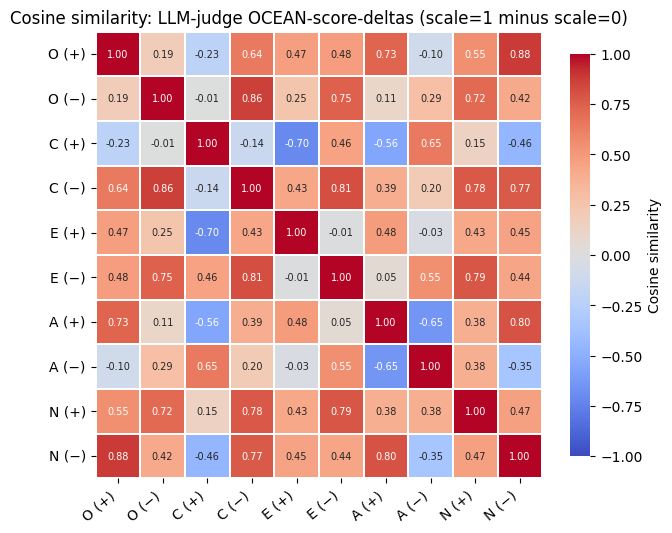

In [14]:
def pretty_label(name: str) -> str:
    """Match `pretty_label` in ocean_flattened_exploration_without_control_models.ipynb."""
    if name.endswith('+'):
        return f'{name[:-1].capitalize()} (+)'
    if name.endswith('-'):
        return f'{name[:-1].capitalize()} (−)'
    return name.capitalize()

def plot_cosine_heatmap(
    df: pd.DataFrame,
    *,
    title: str,
    figsize: tuple[float, float] = (6.5, 5.5),
    annot_fontsize: float = 7.0,
) -> None:
    pretty = [pretty_label(n) for n in df.index]
    df_pretty = df.copy()
    df_pretty.index = pretty
    df_pretty.columns = pretty

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_pretty,
        annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        annot_kws={'fontsize': annot_fontsize},
        cbar_kws={'label': 'Cosine similarity', 'shrink': 0.85},
        square=True,
        linewidths=0.3, linecolor='white',
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

plot_cosine_heatmap(
    cosine_df,
    title='Cosine similarity: LLM-judge OCEAN-score-deltas (scale=1 minus scale=0)',
    figsize=(6.5, 5.5),
)

## Comparison

Compare visually with the adapter-weight cosine heatmap in
`scripts_dev/flatten_loras/ocean_flattened_exploration_without_control_models.ipynb`
(cell `f3b2eb9c`, *"Cosine similarity: persona adapters"*).

Both plots share the same row/column ordering (`o+, o-, c+, c-, e+, e-, a+, a-, n+, n-`)
and the same coolwarm-centered styling, so they can be placed side-by-side.

Expected qualitative pattern:

- Diagonal = 1.0 (each adapter is identical to itself).
- `+` and `-` of the same trait should have strongly negative cosine — opposite
  movement on the trait axis.
- Cross-trait off-diagonals should be smaller in magnitude. The interesting comparison:
  is the cross-trait structure here similar to the cross-trait structure in the
  weight-cosine plot, or do they diverge? Divergence would mean the LoRA weight
  matrices share components that don't translate to behaviorally similar trait shifts.

## Same plot, no base subtraction

For comparison: cosine similarity of the raw `score@scale=1` 5-vectors (without subtracting the base-model 5-vector). Since the base baseline is the same across all 10 adapters for a given trait, this is equivalent to using a different *origin* for the same set of points — so the cosine geometry can change quite a bit (a uniform additive shift to all rows moves the origin and rotates which directions count as 'aligned').

       o+     o-     c+     c-     e+     e-     a+     a-     n+     n-
o+  1.000 -0.408  0.171  0.251  0.218  0.262  0.632 -0.019  0.045  0.626
o- -0.408  1.000  0.540  0.006 -0.655  0.557 -0.061  0.441 -0.422  0.270
c+  0.171  0.540  1.000 -0.530 -0.140  0.989  0.511  0.845 -0.406  0.740
c-  0.251  0.006 -0.530  1.000 -0.415 -0.419 -0.354 -0.454  0.253 -0.199
e+  0.218 -0.655 -0.140 -0.415  1.000 -0.154  0.284 -0.118 -0.367  0.118
e-  0.262  0.557  0.989 -0.419 -0.154  1.000  0.549  0.808 -0.454  0.811
a+  0.632 -0.061  0.511 -0.354  0.284  0.549  1.000  0.041 -0.368  0.857
a- -0.019  0.441  0.845 -0.454 -0.118  0.808  0.041  1.000 -0.228  0.377
n+  0.045 -0.422 -0.406  0.253 -0.367 -0.454 -0.368 -0.228  1.000 -0.586
n-  0.626  0.270  0.740 -0.199  0.118  0.811  0.857  0.377 -0.586  1.000


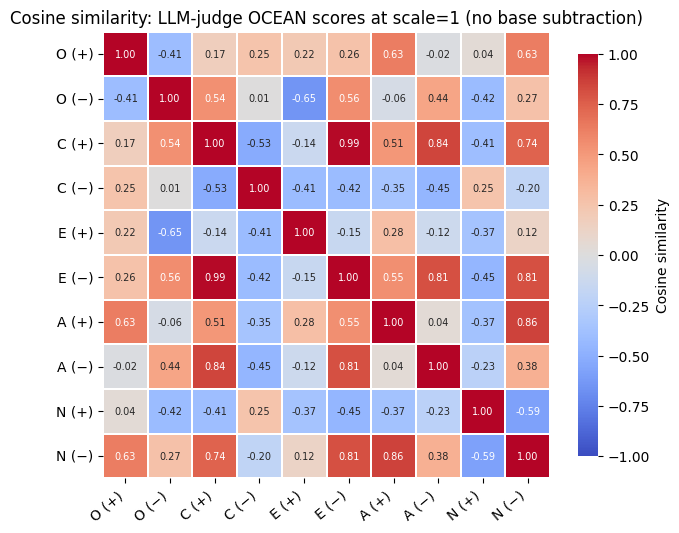

In [15]:
norms_raw = np.linalg.norm(raw_scale1, axis=1, keepdims=True)
norms_raw = np.clip(norms_raw, 1e-12, None)
cosine_raw = (raw_scale1 @ raw_scale1.T) / (norms_raw @ norms_raw.T)

cosine_raw_df = pd.DataFrame(
    cosine_raw,
    index=delta_df.index,
    columns=delta_df.index,
)
print(cosine_raw_df.round(3))

plot_cosine_heatmap(
    cosine_raw_df,
    title='Cosine similarity: LLM-judge OCEAN scores at scale=1 (no base subtraction)',
    figsize=(6.5, 5.5),
)

## Scatter: behavior cosine vs. weight cosine

For each off-diagonal pair of OCEAN± LoRAs, plot the LLM-judge-vector cosine
(this notebook) against the LoRA-weight cosine (from
`ocean_flattened_exploration_without_control_models.ipynb`'s `df_persona`,
pasted below as JSON and loaded into a DataFrame).

Two scatter plots — one using the score-delta cosine (with base subtraction)
and one using the raw scale=1 cosine (no subtraction). Self-terms (i==j) are
always 1.0 by construction, so we drop them.

If the two metrics agree, points lie on a positive-slope diagonal: similar
weights → similar behavior shifts.

/var/folders/qd/cz9h19sd335142892r1531f40000gn/T/ipykernel_67575/895252868.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=8)


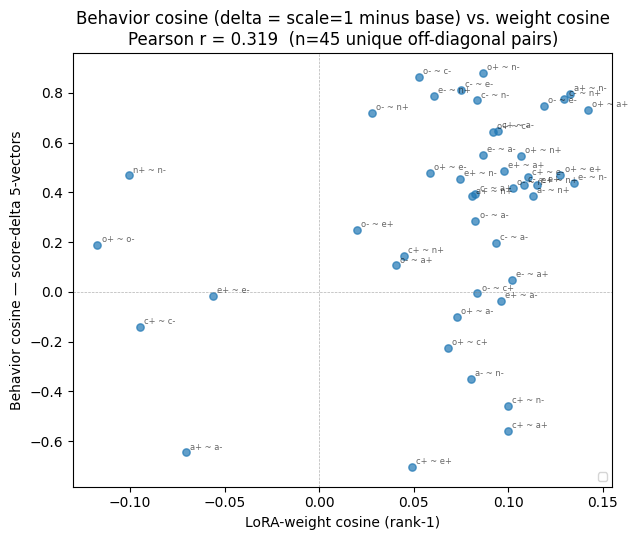

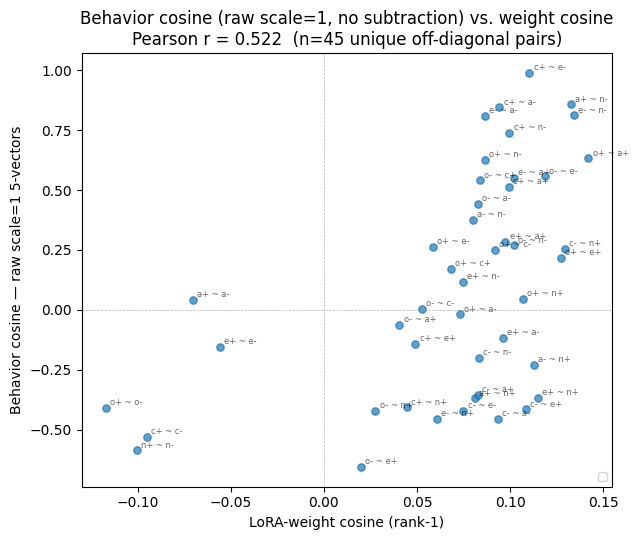

In [17]:
import io

# Pasted from `df.to_json()` of the LoRA-weight cosine matrix in
# scripts_dev/flatten_loras/ocean_flattened_exploration_without_control_models.ipynb
# (cell f3b2eb9c, df_persona).
_WEIGHT_COSINE_JSON = '{"openness+":{"openness+":1.0,"openness-":-0.1172697693,"conscientiousness+":0.0681672916,"conscientiousness-":0.0917059779,"extraversion+":0.1275021583,"extraversion-":0.0583620891,"agreeableness+":0.1420920789,"agreeableness-":0.072950609,"neuroticism+":0.1067468375,"neuroticism-":0.0863942727,"base":0.0},"openness-":{"openness+":-0.1172697768,"openness-":1.0,"conscientiousness+":0.0836191177,"conscientiousness-":0.0528050587,"extraversion+":0.0200009141,"extraversion-":0.1186961308,"agreeableness+":0.0405380428,"agreeableness-":0.082575269,"neuroticism+":0.027696386,"neuroticism-":0.1022482663,"base":0.0},"conscientiousness+":{"openness+":0.0681672916,"openness-":0.0836191177,"conscientiousness+":1.0,"conscientiousness-":-0.0949369818,"extraversion+":0.0491385311,"extraversion-":0.1104333326,"agreeableness+":0.0996323377,"agreeableness-":0.0943029001,"neuroticism+":0.0445855334,"neuroticism-":0.0996669829,"base":0.0},"conscientiousness-":{"openness+":0.0917059779,"openness-":0.0528050549,"conscientiousness+":-0.0949369743,"conscientiousness-":0.9999998808,"extraversion+":0.1084245667,"extraversion-":0.0749676228,"agreeableness+":0.0825967938,"agreeableness-":0.0934339836,"neuroticism+":0.1296111345,"neuroticism-":0.0834711343,"base":0.0},"extraversion+":{"openness+":0.1275021583,"openness-":0.0200009141,"conscientiousness+":0.0491385236,"conscientiousness-":0.1084245667,"extraversion+":0.9999998808,"extraversion-":-0.0560843013,"agreeableness+":0.0975087956,"agreeableness-":0.09621948,"neuroticism+":0.1151291654,"neuroticism-":0.0745306015,"base":0.0},"extraversion-":{"openness+":0.0583620854,"openness-":0.1186961308,"conscientiousness+":0.1104333326,"conscientiousness-":0.0749676153,"extraversion+":-0.056084305,"extraversion-":0.9999999404,"agreeableness+":0.1019718647,"agreeableness-":0.0865187123,"neuroticism+":0.0606800579,"neuroticism-":0.1344522685,"base":0.0},"agreeableness+":{"openness+":0.1420920938,"openness-":0.0405380428,"conscientiousness+":0.0996323451,"conscientiousness-":0.0825967938,"extraversion+":0.0975087956,"extraversion-":0.1019718572,"agreeableness+":1.0,"agreeableness-":-0.0703092739,"neuroticism+":0.0809303001,"neuroticism-":0.132571578,"base":0.0},"agreeableness-":{"openness+":0.072950609,"openness-":0.0825752765,"conscientiousness+":0.0943029001,"conscientiousness-":0.0934339836,"extraversion+":0.09621948,"extraversion-":0.0865187123,"agreeableness+":-0.0703092739,"agreeableness-":1.0,"neuroticism+":0.1127890348,"neuroticism-":0.0801954269,"base":0.0},"neuroticism+":{"openness+":0.1067468449,"openness-":0.0276963841,"conscientiousness+":0.0445855372,"conscientiousness-":0.1296111345,"extraversion+":0.1151291579,"extraversion-":0.0606800616,"agreeableness+":0.0809303001,"agreeableness-":0.1127890274,"neuroticism+":1.0,"neuroticism-":-0.1006488502,"base":0.0},"neuroticism-":{"openness+":0.0863942727,"openness-":0.1022482589,"conscientiousness+":0.0996669829,"conscientiousness-":0.0834711343,"extraversion+":0.0745306015,"extraversion-":0.1344522834,"agreeableness+":0.132571578,"agreeableness-":0.0801954269,"neuroticism+":-0.1006488502,"neuroticism-":1.0000001192,"base":0.0},"base":{"openness+":0.0,"openness-":0.0,"conscientiousness+":0.0,"conscientiousness-":0.0,"extraversion+":0.0,"extraversion-":0.0,"agreeableness+":0.0,"agreeableness-":0.0,"neuroticism+":0.0,"neuroticism-":0.0,"base":0.0}}'

weight_cos_df = pd.read_json(io.StringIO(_WEIGHT_COSINE_JSON))

# Drop the 'base' row/col — the behavior matrix doesn't have it.
weight_cos_df = weight_cos_df.drop(index='base', columns='base')

# Reference notebook uses full trait names ('openness+'); our behavior
# matrix uses single-letter ('o+'). Map full -> short so labels align.
_short_label = {f'{t}{sign}': f'{t[0]}{sign}' for t in OCEAN_TRAITS for sign in ('+', '-')}
weight_cos_df = weight_cos_df.rename(index=_short_label, columns=_short_label)

# Re-order rows/cols to match the behavior matrix (delta_df.index).
weight_cos_df = weight_cos_df.loc[delta_df.index, delta_df.index]

def offdiag_pairs(behavior: pd.DataFrame, weight: pd.DataFrame):
    """Return (x, y, labels) for unique off-diagonal pairs (i < j)."""
    names = list(behavior.index)
    xs, ys, labels = [], [], []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            xs.append(weight.iloc[i, j])
            ys.append(behavior.iloc[i, j])
            labels.append(f'{names[i]} ~ {names[j]}')
    return np.array(xs), np.array(ys), labels

def scatter_pair(
    behavior: pd.DataFrame,
    weight: pd.DataFrame,
    *,
    title: str,
    ylabel: str,
) -> None:
    xs, ys, labels = offdiag_pairs(behavior, weight)
    pearson = np.corrcoef(xs, ys)[0, 1]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(xs, ys, alpha=0.7, s=28)
    # Annotate each point with the pair label.
    for x, y, lbl in zip(xs, ys, labels):
        ax.annotate(lbl, (x, y), fontsize=6, alpha=0.6,
                    xytext=(3, 2), textcoords='offset points')
    # Axes through origin for orientation.
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
    # y=x diagonal as reference.
    lo = min(xs.min(), ys.min())
    hi = max(xs.max(), ys.max())
    margin = 0.05 * (hi - lo)
    # ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
    ax.plot(color='gray', linewidth=0.5, linestyle=':', alpha=0.6, label='y = x')
    ax.set_xlabel('LoRA-weight cosine (rank-1)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nPearson r = {pearson:.3f}  (n={len(xs)} unique off-diagonal pairs)')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

scatter_pair(
    cosine_df,
    weight_cos_df,
    title='Behavior cosine (delta = scale=1 minus base) vs. weight cosine',
    ylabel='Behavior cosine — score-delta 5-vectors',
)

scatter_pair(
    cosine_raw_df,
    weight_cos_df,
    title='Behavior cosine (raw scale=1, no subtraction) vs. weight cosine',
    ylabel='Behavior cosine — raw scale=1 5-vectors',
)